# Détection d'intrusions réseau — CIC-IDS-2017
## Analyse complète en PySpark (sur 100 % des données)

**Tous les calculs** (statistiques, colonnes constantes, variabilité, anomalies IQR, corrélation,
sélection de variables) sont réalisés **en PySpark sur la totalité du dataset** lu depuis HDFS.
`pandas` / `matplotlib` servent **uniquement à dessiner** les graphiques à partir des petits
résultats agrégés renvoyés par Spark.

> **Prérequis** : Hadoop démarré (`jps` → 5 services).

## 1. Connexion Spark, lecture HDFS et préparation (PySpark)

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark import StorageLevel

sns.set_theme(style="whitegrid")

spark = (SparkSession.builder
         .appName("Analyse CIC-IDS-2017 (full Spark)")
         .config("spark.driver.memory", "8g")
         .config("spark.driver.maxResultSize", "2g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("hdfs://localhost:9000/user/projet/unified_dataset.parquet")

label_col = "Label"
feature_cols = [c for c in df.columns if c != label_col]

# Conversion en numérique + neutralisation des infinis/NaN (PySpark)
clean = df
for c in feature_cols:
    clean = clean.withColumn(c, col(c).cast("double"))
for c in feature_cols:
    clean = clean.withColumn(
        c, when((col(c) == float("inf")) | (col(c) == float("-inf")), None).otherwise(col(c)))
# étiquette binaire Normal / Attaque (PySpark)
clean = clean.withColumn("type", when(col(label_col) == "BENIGN", "Normal").otherwise("Attaque"))

clean.persist(StorageLevel.DISK_ONLY)  # cache sur disque, pas dans la JVM (mode local)
n_rows = clean.count()
print(f"Lignes : {n_rows:,} | Colonnes numériques : {len(feature_cols)}")

Lignes : 2,830,743 | Colonnes numériques : 78


## 2. Répartition des classes (PySpark `groupBy`)
Comptage réalisé par Spark sur **toutes** les lignes ; pandas ne fait que tracer.

In [71]:
dist = (clean.groupBy(label_col).count()
              .orderBy("count", ascending=False)
              .toPandas())
dist["pourcentage"] = (dist["count"] / dist["count"].sum() * 100).round(3)
dist

,Label,count,pourcentage
0,BENIGN,2273097,80.300
1,DoS Hulk,231073,8.163
2,PortScan,158930,5.614
3,DDoS,128027,4.523
4,DoS GoldenEye,10293,0.364
5,FTP-Patator,7938,0.280
6,SSH-Patator,5897,0.208
7,DoS slowloris,5796,0.205
8,DoS Slowhttptest,5499,0.194
9,Bot,1966,0.069


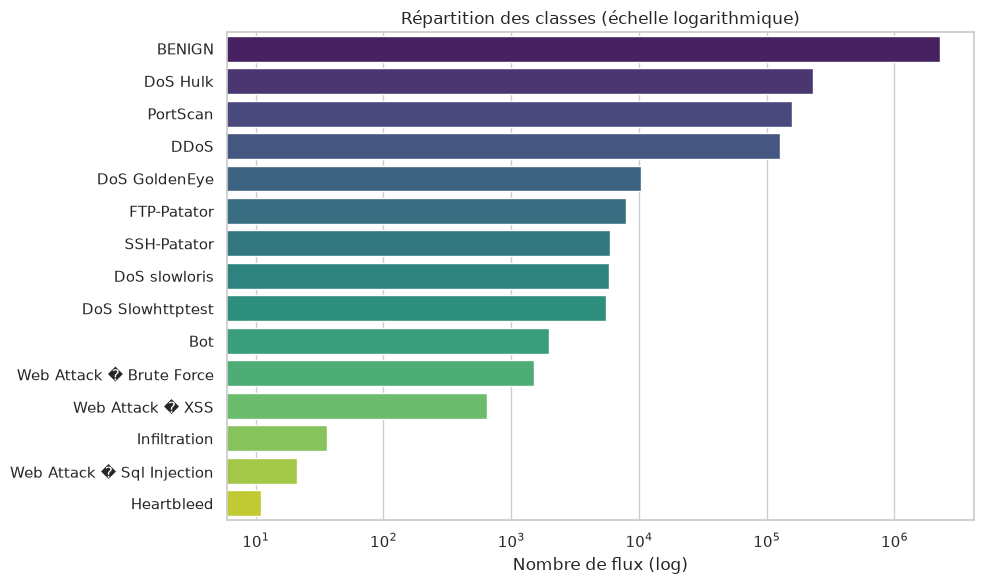

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(data=dist, y=label_col, x="count", hue=label_col, palette="viridis", legend=False)
plt.xscale("log")
plt.title("Répartition des classes (échelle logarithmique)")
plt.xlabel("Nombre de flux (log)"); plt.ylabel("")
plt.tight_layout(); plt.show()

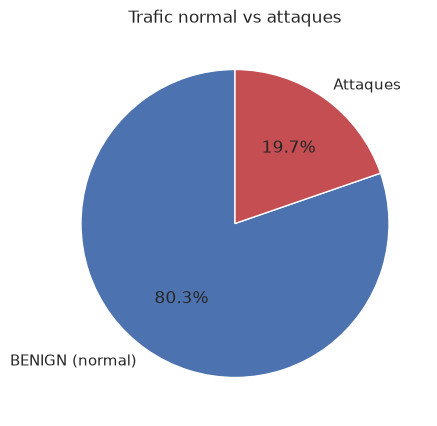

Normal : 2,273,097 | Attaques : 557,646


In [73]:
normal = int(dist.loc[dist[label_col] == "BENIGN", "count"].sum())
attaque = int(dist.loc[dist[label_col] != "BENIGN", "count"].sum())
plt.figure(figsize=(5, 5))
plt.pie([normal, attaque], labels=["BENIGN (normal)", "Attaques"],
        autopct="%1.1f%%", colors=["#4c72b0", "#c44e52"], startangle=90)
plt.title("Trafic normal vs attaques"); plt.show()
print(f"Normal : {normal:,} | Attaques : {attaque:,}")

## 3. Calculs statistiques globaux (PySpark, 100 % des données)
On calcule en **une passe Spark** : quantiles (Q1/Q3/99e), moyenne, écart-type, comptage et
nombre de valeurs aberrantes (IQR) pour **chaque** variable. Ces résultats servent ensuite
aux sections 4 à 8.

In [74]:
# Quantiles approximatifs sur 100% des données (PySpark)
Q = clean.approxQuantile(feature_cols, [0.25, 0.5, 0.75, 0.99], 0.05)
qd = {c: (Q[i] if len(Q[i]) == 4 else [0, 0, 0, 0]) for i, c in enumerate(feature_cols)}

# Une seule agrégation Spark : moyenne, écart-type, comptage, nb d'anomalies (IQR)
agg_exprs = []
for c in feature_cols:
    q1, q3 = qd[c][0], qd[c][2]
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    agg_exprs += [F.mean(c).alias(c + "__mean"),
                  F.stddev(c).alias(c + "__std"),
                  F.count(col(c)).alias(c + "__n")]
    if iqr and iqr > 0:
        agg_exprs.append(F.sum(when((col(c) < lo) | (col(c) > hi), 1).otherwise(0)).alias(c + "__out"))

row = clean.agg(*agg_exprs).collect()[0]
print("Statistiques globales calculées par Spark sur", f"{n_rows:,}", "lignes.")

[Stage 27:==================================================>     (20 + 2) / 22]

Statistiques globales calculées par Spark sur 2,830,743 lignes.


## 4. Statistiques descriptives complètes (PySpark `summary`)
`summary()` calcule moyenne, écart-type, min, max et quartiles côté Spark.

In [75]:
summ = (clean.select([c for c in [
            "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
            "Flow Bytes/s", "Flow Packets/s", "Fwd Packet Length Mean",
            "Bwd Packet Length Mean", "Average Packet Size",
            "Packet Length Mean", "Destination Port"] if c in feature_cols])
        .summary("mean", "stddev", "min", "25%", "50%", "75%", "max")
        .toPandas().set_index("summary").T)
summ

summary,mean,stddev,min,25%,50%,75%,max
Flow Duration,1.4785663929521684E7,3.3653744085855275E7,-13.0,155.0,31315.0,3197931.0,1.19999998E8
Total Fwd Packets,9.361159949878884,749.6727924980004,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,10.393770116185044,997.3882689050921,0.0,1.0,2.0,4.0,291922.0
Flow Bytes/s,NaN,NaN,-2.61E8,119.3126953,4593.644951,166666.6667,NaN
Flow Packets/s,70854.2330626314,254415.43789676361,-2000000.0,3.409519036,109.3493712411,23255.81395,4000000.0
Fwd Packet Length Mean,58.20193852813297,186.0911565496232,0.0,6.0,34.0,50.0,5940.857143
Bwd Packet Length Mean,305.94928134994797,605.2568001421874,0.0,0.0,72.0,181.0,5800.5
Average Packet Size,191.9836575929509,331.86034925418875,0.0,7.5,72.25,149.25,3893.333333
Packet Length Mean,171.9443902489856,305.49146113948655,0.0,6.0,57.2,119.8,3337.142857
Destination Port,8071.482501237308,18283.632172375605,0.0,53.0,80.0,443.0,65535.0


## 5. Colonnes constantes (écart-type nul, calculé par Spark)

In [76]:
const_cols = [c for c in feature_cols if row[c + "__std"] is None or row[c + "__std"] == 0.0]
remaining = [c for c in feature_cols if c not in const_cols]
print(f"Colonnes constantes détectées : {len(const_cols)}")
for c in const_cols:
    print("  -", c)

Colonnes constantes détectées : 8
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate


## 6. Variabilité — coefficient de variation (écart-type / moyenne, Spark)

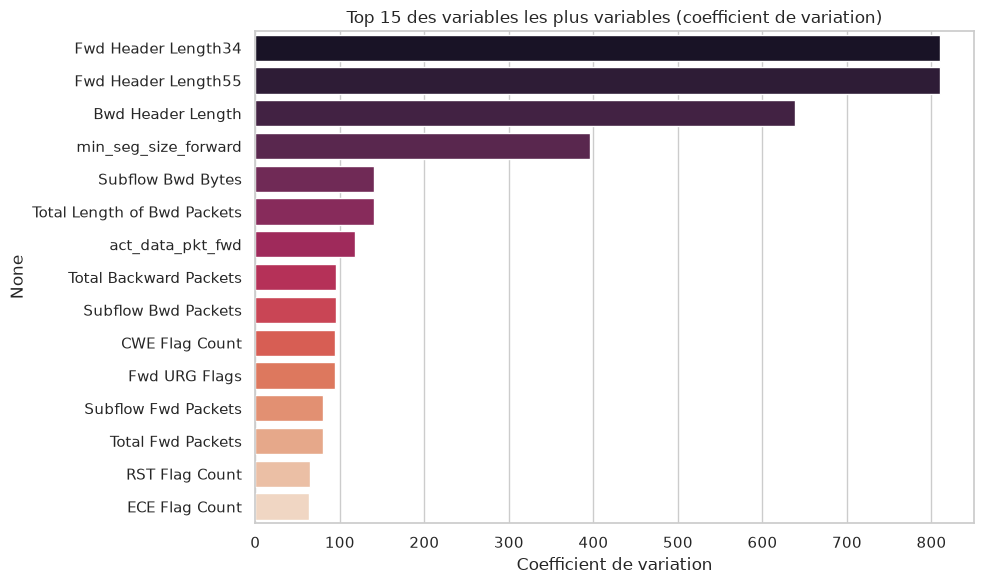

Fwd Header Length34            809.81
Fwd Header Length55            809.81
Bwd Header Length              638.82
min_seg_size_forward           395.74
Subflow Bwd Bytes              140.02
Total Length of Bwd Packets    140.02
act_data_pkt_fwd               117.46
Total Backward Packets          95.96
Subflow Bwd Packets             95.96
CWE Flag Count                  94.79
Fwd URG Flags                   94.79
Subflow Fwd Packets             80.08
Total Fwd Packets               80.08
RST Flag Count                  64.23
ECE Flag Count                  64.09
dtype: float64

In [77]:
cv = {}
for c in feature_cols:
    m, s = row[c + "__mean"], row[c + "__std"]
    if m not in (None, 0) and s is not None:
        cv[c] = abs(s) / abs(m)
cv_top = pd.Series(cv).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=cv_top.values, y=cv_top.index, hue=cv_top.index, palette="rocket", legend=False)
plt.title("Top 15 des variables les plus variables (coefficient de variation)")
plt.xlabel("Coefficient de variation")
plt.tight_layout(); plt.show()
cv_top.round(2)

## 7. Valeurs aberrantes (anomalies) — méthode IQR (comptées par Spark)
Le pourcentage d'anomalies par variable a été calculé dans l'agrégation Spark de la section 3.

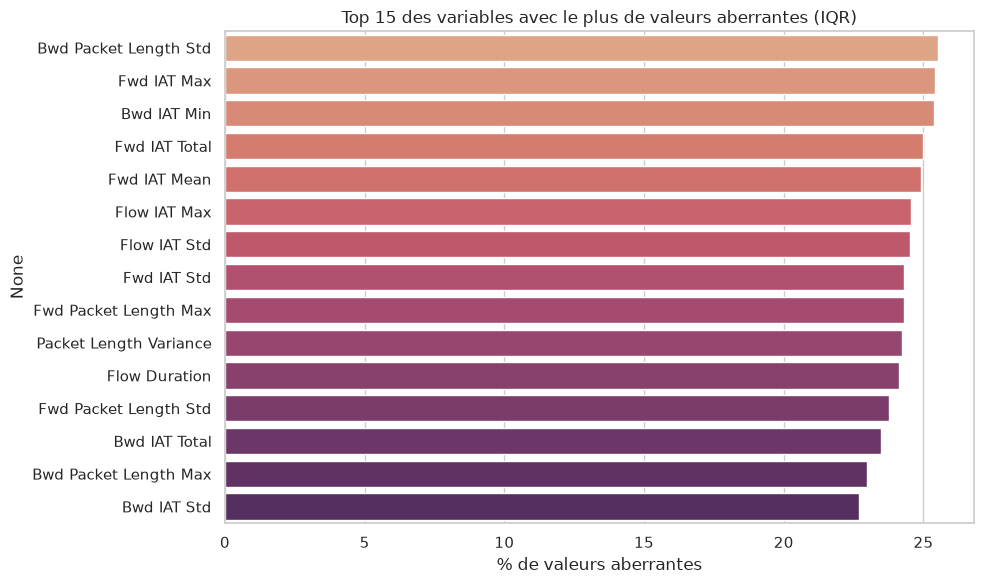

Bwd Packet Length Std     25.53
Fwd IAT Max               25.41
Bwd IAT Min               25.36
Fwd IAT Total             24.98
Fwd IAT Mean              24.90
Flow IAT Max              24.55
Flow IAT Std              24.51
Fwd IAT Std               24.32
Fwd Packet Length Max     24.29
Packet Length Variance    24.24
Flow Duration             24.12
Fwd Packet Length Std     23.76
Bwd IAT Total             23.47
Bwd Packet Length Max     22.98
Bwd IAT Std               22.69
dtype: float64

In [78]:
outliers = {}
for c in feature_cols:
    n = row[c + "__n"]
    if (c + "__out") in row.__fields__ and n:
        outliers[c] = row[c + "__out"] / n * 100
out_top = pd.Series(outliers).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=out_top.values, y=out_top.index, hue=out_top.index, palette="flare", legend=False)
plt.title("Top 15 des variables avec le plus de valeurs aberrantes (IQR)")
plt.xlabel("% de valeurs aberrantes")
plt.tight_layout(); plt.show()
out_top.round(2)

## 8. Histogrammes (comptage des tranches par Spark `RDD.histogram`)
Spark calcule le nombre de flux par tranche sur 100 % des données ; matplotlib dessine les barres.

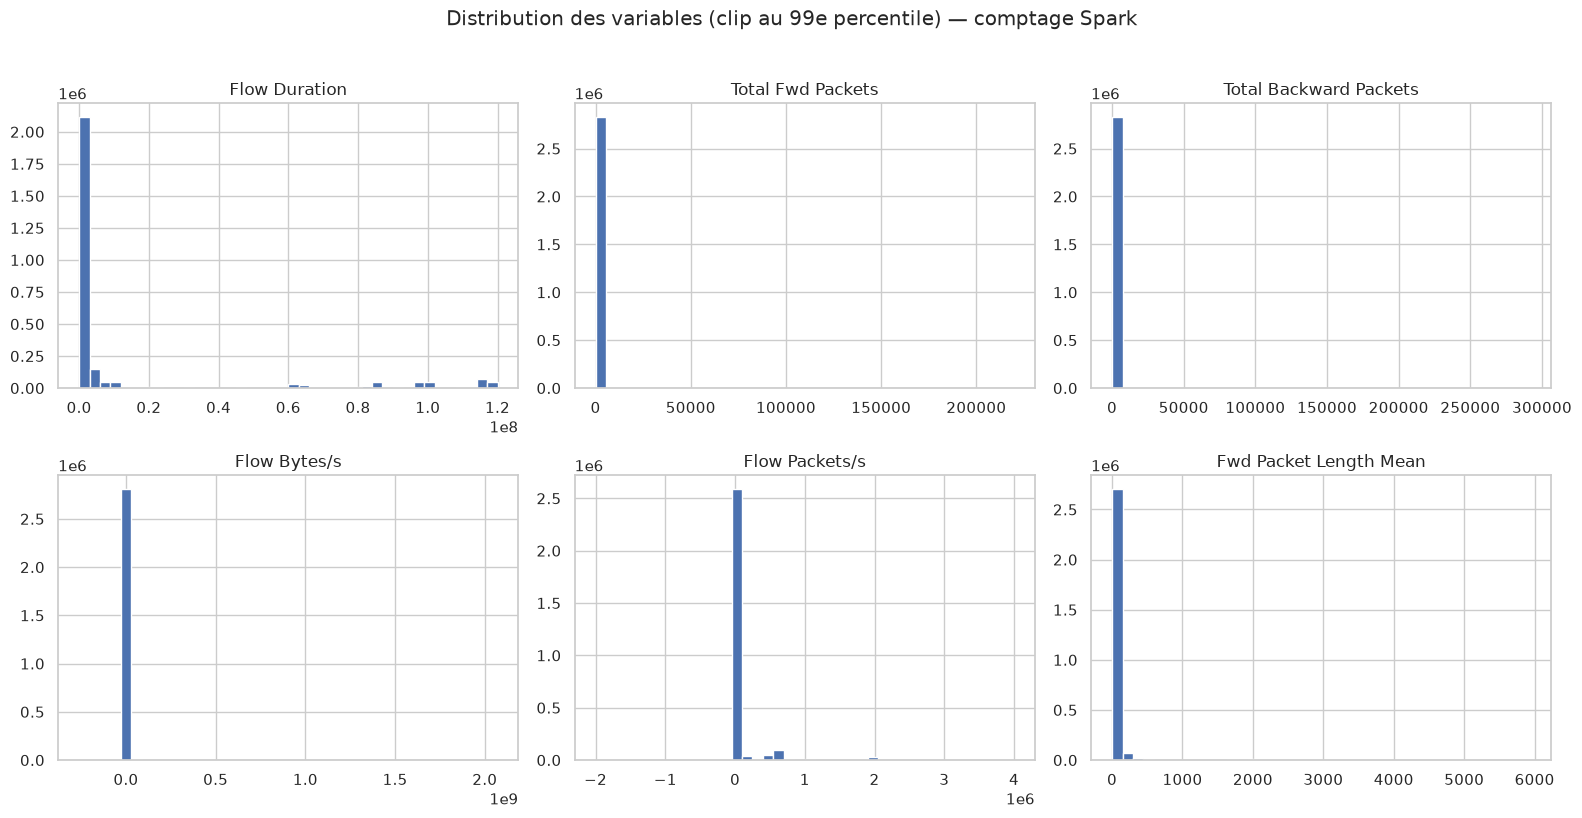

In [79]:
hist_cols = [c for c in ["Flow Duration", "Total Fwd Packets", "Total Backward Packets",
                          "Flow Bytes/s", "Flow Packets/s", "Fwd Packet Length Mean"] if c in feature_cols]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), hist_cols):
    hi = qd[c][3] if qd[c][3] not in (None, 0) else None
    sel = clean.select(col(c).alias("v")).where(col("v").isNotNull())
    if hi:
        sel = sel.where(col("v") <= hi)
    edges, counts = sel.rdd.map(lambda r: r[0]).histogram(40)
    widths = [edges[i+1] - edges[i] for i in range(len(counts))]
    ax.bar(edges[:-1], counts, width=widths, align="edge", color="#4c72b0", edgecolor="white")
    ax.set_title(c)
plt.suptitle("Distribution des variables (clip au 99e percentile) — comptage Spark", y=1.02)
plt.tight_layout(); plt.show()

## 9. Boxplots Normal vs Attaque (5 nombres calculés par Spark `approxQuantile`)
Spark calcule les quartiles par groupe ; matplotlib les dessine via `ax.bxp` (aucune donnée brute ramenée).

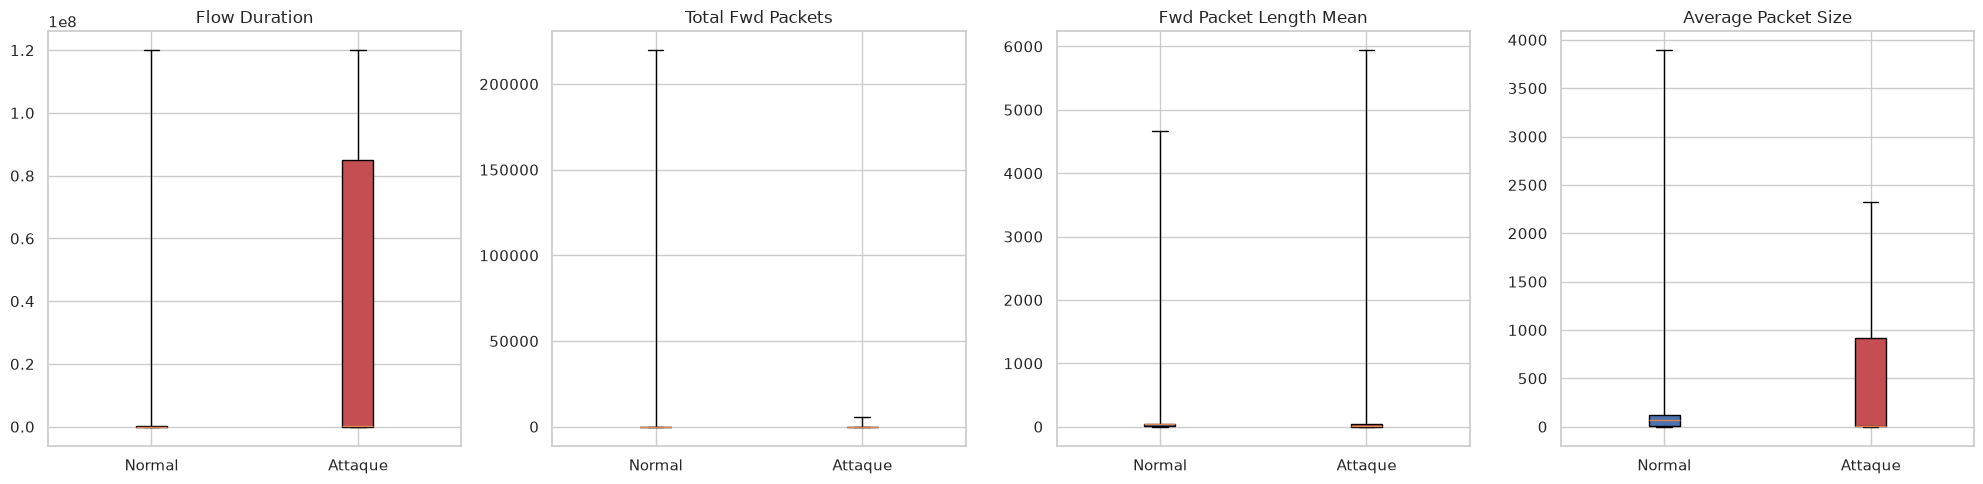

In [80]:
cols_box = [c for c in ["Flow Duration", "Total Fwd Packets", "Fwd Packet Length Mean", "Average Packet Size"] if c in feature_cols]
box_stats = {c: {} for c in cols_box}
for grp in ["Normal", "Attaque"]:
    sub = clean.filter(col("type") == grp)
    qs = sub.approxQuantile(cols_box, [0.05, 0.25, 0.5, 0.75, 0.95], 0.05)
    for c, q in zip(cols_box, qs):
        box_stats[c][grp] = q

fig, axes = plt.subplots(1, len(cols_box), figsize=(5 * len(cols_box), 5))
for ax, c in zip(np.atleast_1d(axes), cols_box):
    bxp = []
    for grp in ["Normal", "Attaque"]:
        p = box_stats[c][grp]
        bxp.append({"label": grp, "whislo": p[0], "q1": p[1], "med": p[2],
                    "q3": p[3], "whishi": p[4], "fliers": []})
    bp = ax.bxp(bxp, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#4c72b0", "#c44e52"]):
        patch.set_facecolor(color)
    ax.set_title(c)
plt.tight_layout(); plt.show()

## 9 bis. Influence des valeurs aberrantes (avant / après suppression)

On garde le graphique de la section 9 (**avec** les anomalies, qui écrasent la visualisation), puis on **supprime les valeurs aberrantes** (méthode IQR) et on refait les **mêmes boxplots** pour **comparer** et montrer l'influence des anomalies.

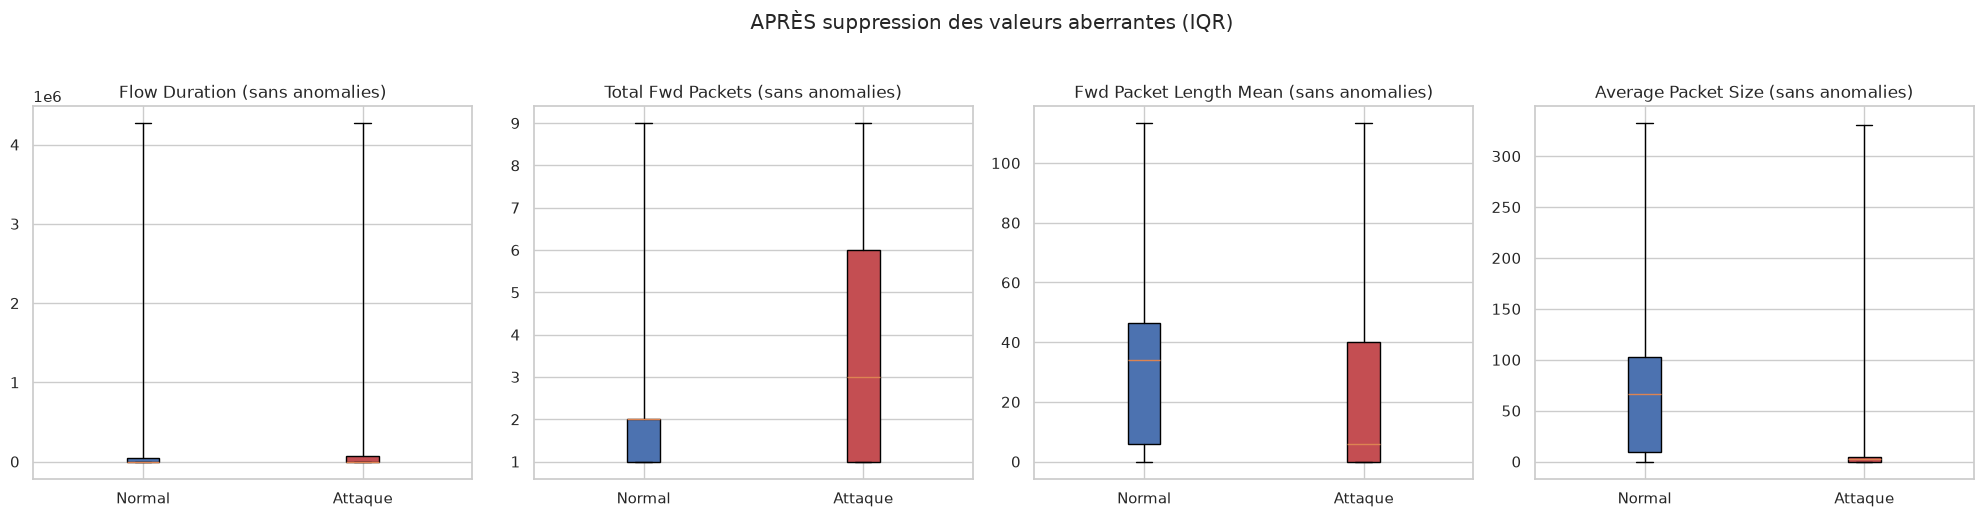

In [81]:
# Suppression des valeurs aberrantes (IQR) puis MÊMES boxplots — comparaison avec la section 9
box_stats_clean = {c: {} for c in cols_box}
for c in cols_box:
    q1, q3 = qd[c][0], qd[c][2]        # quartiles déjà calculés en section 3
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    sans_out = clean.filter((col(c) >= lo) & (col(c) <= hi))   # on retire les anomalies de cette variable
    for grp in ["Normal", "Attaque"]:
        sub = sans_out.filter(col("type") == grp)
        box_stats_clean[c][grp] = sub.approxQuantile(c, [0.05, 0.25, 0.5, 0.75, 0.95], 0.05)

fig, axes = plt.subplots(1, len(cols_box), figsize=(5 * len(cols_box), 5))
for ax, c in zip(np.atleast_1d(axes), cols_box):
    bxp = []
    for grp in ["Normal", "Attaque"]:
        p = box_stats_clean[c][grp]
        bxp.append({"label": grp, "whislo": p[0], "q1": p[1], "med": p[2],
                    "q3": p[3], "whishi": p[4], "fliers": []})
    bp = ax.bxp(bxp, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#4c72b0", "#c44e52"]):
        patch.set_facecolor(color)
    ax.set_title(c + " (sans anomalies)")
plt.suptitle("APRÈS suppression des valeurs aberrantes (IQR)", y=1.03)
plt.tight_layout(); plt.show()

## 10. Matrice de corrélation et redondances (PySpark MLlib `Correlation`)
La corrélation est calculée par Spark sur 100 % des données via un `VectorAssembler`.

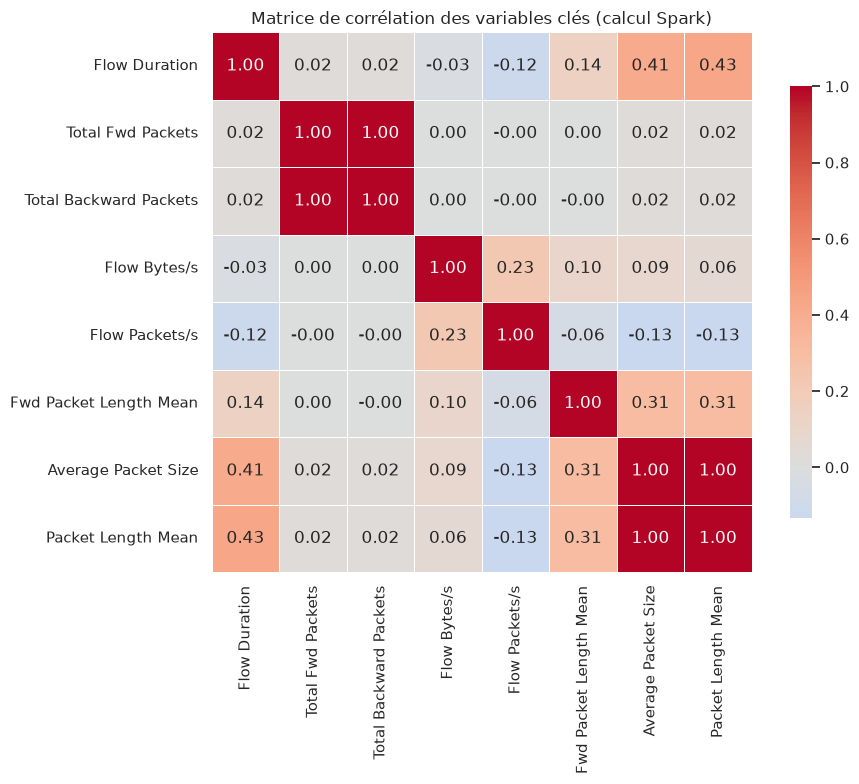

In [82]:
assembler = VectorAssembler(inputCols=remaining, outputCol="__features", handleInvalid="skip")
vec = assembler.transform(clean.select(remaining))
corr_matrix = Correlation.corr(vec, "__features", "pearson").collect()[0][0].toArray()

# Heatmap sur les variables clés
key_features = [c for c in ["Flow Duration", "Total Fwd Packets", "Total Backward Packets",
                            "Flow Bytes/s", "Flow Packets/s", "Fwd Packet Length Mean",
                            "Average Packet Size", "Packet Length Mean"] if c in remaining]
idx = [remaining.index(c) for c in key_features]
sub_corr = pd.DataFrame(corr_matrix[np.ix_(idx, idx)], index=key_features, columns=key_features)
plt.figure(figsize=(10, 8))
sns.heatmap(sub_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation des variables clés (calcul Spark)")
plt.tight_layout(); plt.show()

In [83]:
# Paires redondantes (|corr| > 0.9) à partir de la matrice Spark
pairs = []
for i in range(len(remaining)):
    for j in range(i + 1, len(remaining)):
        v = abs(corr_matrix[i][j])
        if not np.isnan(v) and v > 0.9:
            pairs.append((remaining[i], remaining[j], round(v, 3)))
red_df = pd.DataFrame(pairs, columns=["Variable A", "Variable B", "Corrélation"]).sort_values("Corrélation", ascending=False)
print(f"Paires redondantes (|corr| > 0.9) : {len(red_df)}")
red_df.head(20)

Paires redondantes (|corr| > 0.9) : 71


,Variable A,Variable B,Corrélation
3,Total Fwd Packets,Subflow Fwd Packets,1.000
50,Fwd URG Flags,CWE Flag Count,1.000
26,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000
15,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000
13,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000
10,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000
8,Total Backward Packets,Subflow Bwd Packets,1.000
51,Fwd Header Length34,Fwd Header Length55,1.000
49,Fwd PSH Flags,SYN Flag Count,1.000
64,Subflow Fwd Packets,Subflow Bwd Packets,0.999


## 11. Sélection de variables
Suppression des colonnes constantes puis d'une variable par paire redondante.

In [84]:
to_drop = set(const_cols)
for a, b, v in pairs:
    if a not in to_drop and b not in to_drop:
        to_drop.add(b)
kept = [c for c in feature_cols if c not in to_drop]
print(f"Variables initiales : {len(feature_cols)}")
print(f"  - constantes       : {len(const_cols)}")
print(f"  - redondantes      : {len(to_drop) - len(const_cols)}")
print(f"  => conservées      : {len(kept)}")

Variables initiales : 78
  - constantes       : 8
  - redondantes      : 28
  => conservées      : 42


## 12. Conclusion

- **Tout est calculé en PySpark sur la totalité des données** (2,8 M de lignes) : stats, variabilité,
  anomalies (IQR), corrélation, sélection. pandas/matplotlib ne servent qu'à **dessiner**.
- **Déséquilibre** marqué : ~80 % de trafic normal (`BENIGN`).
- **Variables discriminantes** : durée, nombre de paquets, taille moyenne (voir boxplots).
- **Anomalies** : plusieurs variables riches en valeurs aberrantes (cohérent avec les attaques).
- **Nettoyage / sélection** : colonnes constantes et redondantes retirées → jeu de variables réduit.

> Étape suivante : entraînement Random Forest (`train_model.py`) sur le dataset nettoyé.

In [85]:
spark.stop()